In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
# Temperatures to calculate the cooling rate
tags_cooling = [
    "temp_1_23062026A_purewater",
    "temp_1_23062026O_purewater",
    "temp_1_24062026_purewater",
    "temp_2_23062026A_purewater",
    "temp_2_24062026_purewater",
    "2_0618",
    "2_0622A",
]

cooling_rates = [] 

# computing the cooling rate
for tag in tags_cooling:
    #importing data and making time array
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    t = np.arange(len(T))/60  # time in minutes
    #calculating average cooling rate
    slope, intercept, r, p, stderr = linregress(t,T)
    cooling_rates.append(slope)
    print(f"{tag}: {slope:.3f} ± {stderr:.3f} °C/min, R^2 = {r**2:.4f}")

cooling_rates = np.array(cooling_rates)

#computing average and std across all experiments
mean_rate = np.mean(cooling_rates)
std_rate = np.std(cooling_rates, ddof=1)
print(f"Overall cooling rate = {mean_rate:.3f} ± {std_rate:.3f} °C/min")

temp_1_23062026A_purewater: -0.632 ± 0.001 °C/min, R^2 = 0.9947
temp_1_23062026O_purewater: -0.653 ± 0.001 °C/min, R^2 = 0.9951
temp_1_24062026_purewater: -0.563 ± 0.001 °C/min, R^2 = 0.9921
temp_2_23062026A_purewater: -0.620 ± 0.001 °C/min, R^2 = 0.9940
temp_2_24062026_purewater: -0.563 ± 0.001 °C/min, R^2 = 0.9921
2_0618: -0.582 ± 0.001 °C/min, R^2 = 0.9946
2_0622A: -0.636 ± 0.001 °C/min, R^2 = 0.9943
Overall cooling rate = -0.607 ± 0.037 °C/min


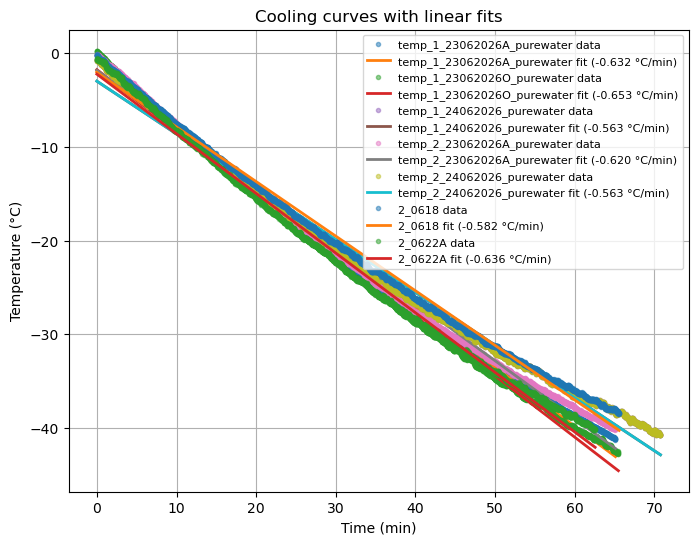

Overall cooling rate = -0.607 ± 0.037 °C/min


In [3]:
# Plotting the cooling rates with a fit line through it
cooling_rates = []

plt.figure(figsize=(8,6))

for tag in tags_cooling:
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    t = np.arange(len(T))/60  # time in minutes

    slope, intercept, r, p, stderr = linregress(t, T)
    cooling_rates.append(slope)

    # Plot measured data
    plt.plot(t, T, '.', alpha=0.5, label=f"{tag} data")

    # Plot fitted cooling line
    plt.plot(t, slope*t + intercept, '-', linewidth=2,
             label=f"{tag} fit ({slope:.3f} °C/min)")

plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Cooling curves with linear fits")
plt.legend(fontsize=8)
plt.grid(True)
plt.savefig("cooling_rates.png", dpi=1000, bbox_inches = "tight")
plt.show()

cooling_rates = np.array(cooling_rates)

mean_rate = np.mean(cooling_rates)
std_rate = np.std(cooling_rates, ddof=1)

print(f"Overall cooling rate = {mean_rate:.3f} ± {std_rate:.3f} °C/min")

In [4]:
# tags for the ambient (lab) temperature
tags_ambient = ["3_0618",
                "3_0622A",
                "3_0623A",
                "3_0623O",
                "3_0624"
               ]
#computing average lab temperature and standard deviation
for tag in tags_ambient:
    T = np.loadtxt(f"C:/BEP/Temperatures/{tag}.txt")
    mean_temp = np.mean(T)
    print(f"Average lab temperature for {tag}: {np.round(mean_temp,3)} ± {np.std(mean_temp)} °C")

Average lab temperature for 3_0618: 23.838 ± 0.0 °C
Average lab temperature for 3_0622A: 25.731 ± 0.0 °C
Average lab temperature for 3_0623A: 26.236 ± 0.0 °C
Average lab temperature for 3_0623O: 25.262 ± 0.0 °C
Average lab temperature for 3_0624: 26.688 ± 0.0 °C
